# Part 02: Dataset Quality & Exploratory Data Analysis (EDA)

## Project: Agastya – AI Contract Analysis System (Phase 1)

This notebook supports the coursework column **Dataset Quality & EDA** in the evaluation rubric. Strong performance requires more than screenshots of `head()` / `tail()`:

- **Describe** sources, schema, and units of analysis (contract vs clause vs category).
- **Quality checks:** missing values, duplicates, consistency with auxiliary files (`full_contract_txt/`).
- **Summaries with interpretation:** class imbalance, text-length distributions (skew / heavy tails), obvious outliers.
- **Link to modeling:** which metrics matter (e.g. macro-F1 under imbalance), split discipline (document-level), preprocessing (placeholders, trimming).

**Dataset:** CUAD v1 — [Contract Understanding Atticus Dataset](https://www.atticusprojectai.org/cuad) (510 commercial contracts, 41 clause categories).

**Phase 1 context:** clause-level classification with classical ML (e.g. TF-IDF + SVM). CUAD stores **clause context** and **answer** per category; for many Yes/No fields, **No** is represented with placeholder clause text `[]`, while **Yes** carries substantive text.

## 0. Environment and paths

Data lives under `data/CUAD_v1/`. `PROJECT_ROOT` assumes this notebook is in `notebooks/Phase 1/`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path("../..").resolve()
CUAD_DIR = PROJECT_ROOT / "data" / "CUAD_v1"
MASTER_CSV = CUAD_DIR / "master_clauses.csv"
CUAD_JSON = CUAD_DIR / "CUAD_v1.json"
TXT_DIR = CUAD_DIR / "full_contract_txt"

assert MASTER_CSV.is_file(), f"Missing {MASTER_CSV}"
assert CUAD_JSON.is_file(), f"Missing {CUAD_JSON}"
assert TXT_DIR.is_dir(), f"Missing {TXT_DIR}"
print("CUAD_DIR:", CUAD_DIR)

CUAD_DIR: /Users/subhammahapatra/Downloads/Projects/Agastya/data/CUAD_v1


## 1. Schema and master table

Per CUAD README: **83 columns** = `Filename` + 41 *(context, answer)* pairs. We verify pairing programmatically (not only by eye).

In [2]:
df = pd.read_csv(MASTER_CSV, low_memory=False)
cols = list(df.columns)
category_pairs: list[tuple[str, str]] = [(cols[i], cols[i + 1]) for i in range(1, len(cols), 2)]

print("Shape (contracts × columns):", df.shape)
print("Category pairs:", len(category_pairs))
df.iloc[:2, :6]

Shape (contracts × columns): (510, 83)
Category pairs: 41


,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...","['8th day of May 2014', 'May 8, 2014']"
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.', 'Rogers', 'Rogers...","Rogers Cable Communications Inc. (""Rogers""); E...","['July 11 , 2006']"


## 2. Integrity: duplicates, filenames, alignment with `full_contract_txt/`

**Rubric:** fixing standard issues (duplicates, missing keys) and showing *awareness* of integration errors.

The CSV `Filename` often ends in `.pdf` or `.PDF` while plain text lives beside it with `.txt`. We normalize extensions before checking path existence.

In [3]:
fn = df["Filename"].astype(str)
print("Duplicate Filename:", int(fn.duplicated().sum()))
print("Blank Filename:", int(fn.str.strip().eq("").sum()))


def pdf_stem_to_txt_name(pdf_name: str) -> str:
    base = pdf_name
    for suf in (".pdf", ".PDF"):
        if base.endswith(suf):
            return base[: -len(suf)] + ".txt"
    return base if base.endswith(".txt") else base + ".txt"

expected_txt = fn.map(pdf_stem_to_txt_name)
exists_mask = expected_txt.map(lambda t: (TXT_DIR / t).is_file())
n_miss = int((~exists_mask).sum())
print("Rows without matching .txt in full_contract_txt/:", n_miss)
if n_miss:
    display(df.loc[~exists_mask, ["Filename"]].head(12))

Duplicate Filename: 0
Blank Filename: 0
Rows without matching .txt in full_contract_txt/: 11


,Filename
286,PLAYAHOTELS&RESORTSNV_03_14_2017-EX-10.22-STRA...
294,"MACY'S,INC_05_11_2020-EX-99.4-JOINT FILING AGR..."
325,MOELIS&CO_03_24_2014-EX-10.19-STRATEGIC ALLIAN...
360,KALLOINC_11_03_2011-EX-10.1-STRATEGIC ALLIANCE...
442,ELECTRAMECCANICA VEHICLES CORP. - Manufacturin...
469,Monsanto Company - SECOND A&R EXCLUSIVE AGENCY...
474,"PACIRA PHARMACEUTICALS, INC. - A&R STRATEGIC L..."
475,Principal Life Insurance Company - Broker Deal...
476,"Reinsurance Group of America, Incorporated - A..."
477,"SightLife Surgical, Inc. - STRATEGIC SALES & M..."


## 3. Long format (contract × category)

Each row below is one *(contract, category)*. We mark **`has_real_clause`** when context text is present and not the placeholder `[]` (typical for **No** in Yes/No categories). This definition matches how we will form **positive training examples** for span/clause tasks.

In [4]:
PLACEHOLDER_CLAUSE = {"[]", ""}

rows: list[dict] = []
for _, r in df.iterrows():
    file = str(r["Filename"])
    for ctxt_col, ans_col in category_pairs:
        clause = r[ctxt_col]
        ans = r[ans_col]
        c_str = "" if pd.isna(clause) else str(clause).strip()
        a_str = "" if pd.isna(ans) else str(ans).strip()
        is_ph = c_str in PLACEHOLDER_CLAUSE
        rows.append(
            {
                "filename": file,
                "category": ctxt_col,
                "clause_text": c_str,
                "answer": a_str,
                "has_real_clause": (not is_ph),
                "char_len": len(c_str),
                "word_len": len(c_str.split()) if c_str else 0,
            }
        )

long_df = pd.DataFrame(rows)
print("Long-table rows:", len(long_df))
long_df.head(4)

Long-table rows: 20910


,filename,category,clause_text,answer,has_real_clause,char_len,word_len
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Document Name,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,True,33,3
1,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Parties,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', ...","Birch First Global Investments Inc. (""Company""...",True,112,13
2,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Agreement Date,"['8th day of May 2014', 'May 8, 2014']",5/8/14,True,38,8
3,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Effective Date,['This agreement shall begin upon the date of ...,,True,104,18


## 4. Class imbalance (Yes/No categories)

For categories whose answers are only **Yes** / **No**, the fraction of **Yes** is the **positive class prevalence**. Wide spread across categories implies **strong imbalance** — a reason to emphasize **macro-averaged F1**, **per-class recall**, or **class weights** rather than accuracy alone (rubric: connect EDA to metrics).

In [5]:
def category_answer_profile(answers: pd.Series) -> dict:
    a = answers.astype(str).str.strip()
    uniq = set(a.unique()) - {""}
    is_yesno = uniq <= {"Yes", "No"} and len(uniq) > 0
    if is_yesno:
        return {"kind": "yes_no", "positive_rate_yes": float((a == "Yes").mean()), "n_distinct_answers": len(uniq)}
    nonempty = a.ne("") & ~a.str.lower().eq("nan")
    return {
        "kind": "other",
        "nonempty_answer_rate": float(nonempty.mean()),
        "n_distinct_answers": int(a.nunique()),
    }


rows_cs: list[dict] = []
for cat, g in long_df.groupby("category", sort=False):
    prof = category_answer_profile(g["answer"])
    prof["category"] = cat
    rows_cs.append(prof)

cat_stats = pd.DataFrame(rows_cs).set_index("category")
yesno = cat_stats[cat_stats["kind"] == "yes_no"].sort_values("positive_rate_yes")
print("Yes/No categories:", len(yesno), "| Other:", int((cat_stats["kind"] != "yes_no").sum()))
yesno.round(4)

Yes/No categories: 33 | Other: 8


,kind,nonempty_answer_rate,n_distinct_answers,positive_rate_yes
category,,,,
Source Code Escrow,yes_no,NaN,2,0.0255
Price Restrictions,yes_no,NaN,2,0.0294
Unlimited/All-You-Can-Eat-License,yes_no,NaN,2,0.0333
Affiliate License-Licensor,yes_no,NaN,2,0.0451
Most Favored Nation,yes_no,NaN,2,0.0549
Third Party Beneficiary,yes_no,NaN,2,0.0647
No-Solicit Of Customers,yes_no,NaN,2,0.0667
Non-Disparagement,yes_no,NaN,2,0.0745
Joint Ip Ownership,yes_no,NaN,2,0.0902


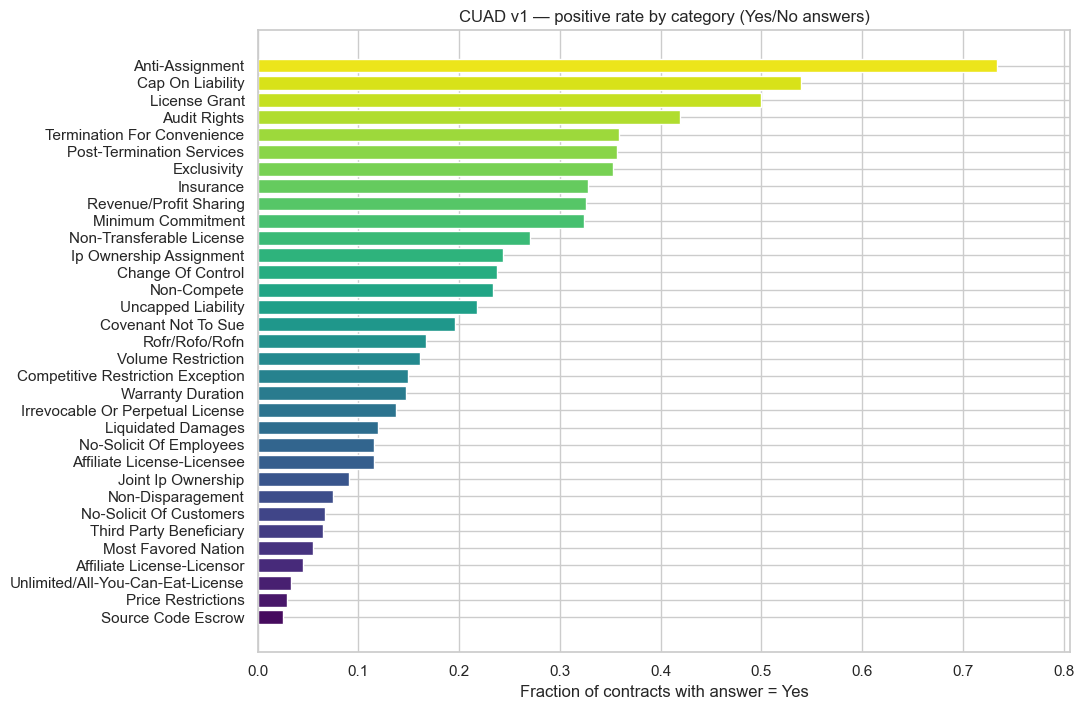

Yes-rate min/max: 0.025490196078431372 0.7333333333333333


In [6]:
fig, ax = plt.subplots(figsize=(11, max(6, len(yesno) * 0.22)))
y = yesno["positive_rate_yes"].sort_values()
ax.barh(y.index, y.values, color=sns.color_palette("viridis", n_colors=len(y)))
ax.set_xlabel("Fraction of contracts with answer = Yes")
ax.set_title("CUAD v1 — positive rate by category (Yes/No answers)")
ax.set_xlim(0, max(0.05, float(y.max()) * 1.1))
plt.tight_layout()
plt.show()
print("Yes-rate min/max:", float(y.min()), float(y.max()))

## 5. Text length distribution (heavy tail)

**Rubric (higher bands):** characterize distributions — not only plot histograms. Clause **word counts** under `has_real_clause` are typically **right-skewed** with **high kurtosis**: a few very long spans dominate the upper tail. That motivates **trimming/capping** for some vectorizers, or **per-document sampling** when training, and it explains why naive length-unaware baselines can struggle.

count    6702.000000
mean       83.723665
std       134.692671
min         1.000000
50%        43.000000
90%       196.000000
95%       300.950000
99%       678.990000
max      2566.000000
Name: word_len, dtype: float64
skew: 5.14601619796382 excess kurtosis: 45.52005024689774


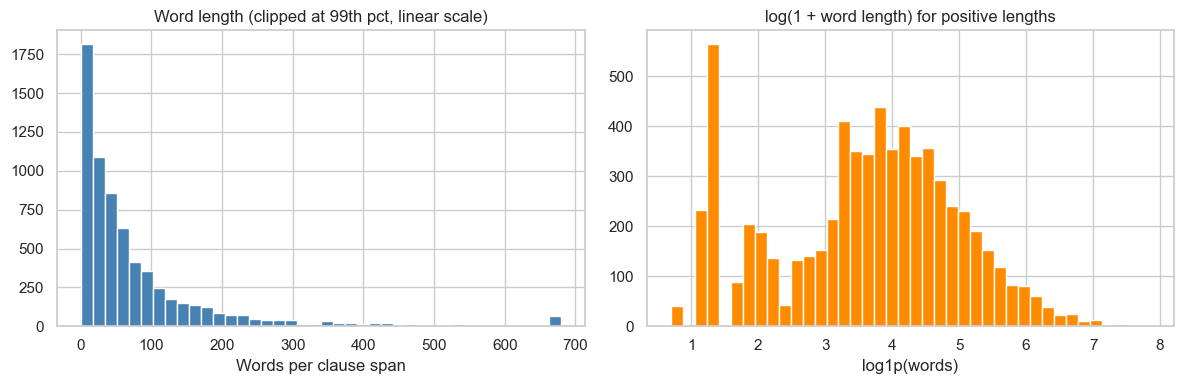

In [7]:
sub = long_df.loc[long_df["has_real_clause"], "word_len"]
desc = sub.describe(percentiles=[0.5, 0.9, 0.95, 0.99])
print(desc)
print("skew:", float(sub.skew()), "excess kurtosis:", float(sub.kurtosis()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sub.clip(upper=sub.quantile(0.99)), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Word length (clipped at 99th pct, linear scale)")
axes[0].set_xlabel("Words per clause span")

pos = sub[sub > 0]
axes[1].hist(np.log1p(pos), bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("log(1 + word length) for positive lengths")
axes[1].set_xlabel("log1p(words)")
plt.tight_layout()
plt.show()

## 6. Contract-level label density

How many **real** clause spans does each contract contribute across all categories? This shows whether a few documents carry most of the positive labels (useful for stratified **document-level** splits).

count    510.000000
mean      13.141176
std        5.912897
min        2.000000
50%       13.000000
90%       21.100000
95%       23.000000
99%       26.910000
max       32.000000
Name: has_real_clause, dtype: float64


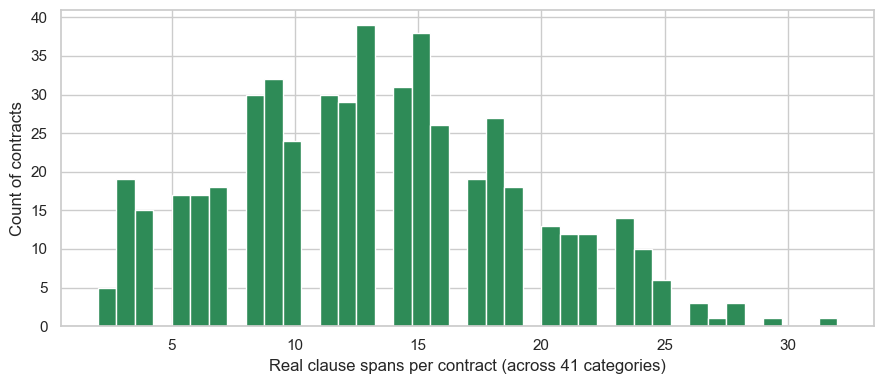

In [8]:
per_doc = long_df.groupby("filename")["has_real_clause"].sum()
print(per_doc.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(per_doc, bins=40, color="seagreen", edgecolor="white")
ax.set_xlabel("Real clause spans per contract (across 41 categories)")
ax.set_ylabel("Count of contracts")
plt.tight_layout()
plt.show()

## 7. SQuAD-style JSON (sanity check)

`CUAD_v1.json` mirrors SQuAD 2.0: paragraphs with `qas` and `is_impossible`. A quick aggregate confirms the JSON is aligned with **510** contracts and provides **span** targets for QA-style models (outside strict Phase 1 classical pipeline, but relevant for data understanding).

In [9]:
with open(CUAD_JSON, encoding="utf-8") as f:
    squad = json.load(f)
docs = squad["data"]
print("Documents in JSON:", len(docs))
n_para = sum(len(d["paragraphs"]) for d in docs)
print("Total paragraphs:", n_para)
imp = 0
tot_q = 0
for d in docs:
    for p in d["paragraphs"]:
        for qa in p["qas"]:
            tot_q += 1
            if qa.get("is_impossible"):
                imp += 1
print("Questions (qas):", tot_q, "| is_impossible:", imp, f"({imp/tot_q:.1%})")

Documents in JSON: 510
Total paragraphs: 510
Questions (qas): 20910 | is_impossible: 14208 (67.9%)


## 8. Leakage, splits, and limitations (rubric: nuance)

- **Document leakage:** If chunks from the same contract appear in both train and test, metrics can be **optimistic** because lexical and party-specific cues repeat. **Mitigation:** split by **`Filename`** (or official CUAD train/test lists if you use them).
- **Placeholders:** Treating `[]` as “no span” aligns with Yes/No semantics; do this **consistently** in training data construction.
- **Multi-label reality:** One contract has many categories; tasks can be framed as **41 binary** problems or **multi-class** on extracted spans — EDA above supports either, but the choice should match your Phase 1 notebook.

---

### Short summary table

| Finding | Implication for Phase 1 |
|--------|---------------------------|
| Strong **Yes-rate** variation across categories | Prefer **macro-F1** / per-class metrics; consider **class weights** |
| **Heavy-tailed** clause lengths | Watch vectorizer settings / outliers; consider max features or length caps |
| **Filename ↔ txt** join quirks | Normalize `.pdf`/`.PDF` before merging with raw text |
| Same contract, many labels | **Document-level** holdout for honest evaluation |

## 9. Deeper checks (consistency & file alignment)

Earlier outputs showed **11** master-CSV contracts whose expected `.txt` path was missing under `full_contract_txt/`. That blocks joins if you need **full-contract text** alongside labels.

Here we verify two things:

1. **Yes/No ↔ placeholder convention:** For the 33 binary categories, **No** should pair with clause text `[]` and **Yes** with a non-empty span (see CUAD README). Counting violations makes preprocessing auditable for the rubric.
2. **Filename recovery hints:** For mismatches, we suggest the closest `.txt` filename on disk (character-level similarity). This does **not** assert correctness—manual spot-checks are still needed for `&`, apostrophes, or renamed stems.

In [10]:
# --- 9a) Yes/No answers vs [] placeholder ---
yn_cats = set(yesno.index)
sub_yn = long_df[long_df["category"].isin(yn_cats)].copy()
a = sub_yn["answer"].astype(str).str.strip()
c = sub_yn["clause_text"].astype(str).str.strip()

no_mask = a.eq("No")
yes_mask = a.eq("Yes")
# "No" should use empty placeholder [] (not other text)
bad_no = sub_yn[no_mask & ~c.eq("[]")]
# "Yes" should carry real clause text
bad_yes = sub_yn[yes_mask & ~sub_yn["has_real_clause"]]

print("Yes/No rows (33 categories × 510 contracts):", len(sub_yn))
print("Violations: answer=No but clause_text != '[]':", len(bad_no))
print("Violations: answer=Yes but no real clause span:", len(bad_yes))
if len(bad_no):
    display(bad_no[["filename", "category", "clause_text", "answer"]].head(8))
if len(bad_yes):
    display(bad_yes[["filename", "category", "clause_text", "answer"]].head(8))

# --- 9b) Quantify label imbalance spread (beyond min/max) ---
pr = yesno["positive_rate_yes"].astype(float)
print("\nYes-rate across Yes/No categories: mean={:.1%}, std={:.1%}, median={:.1%}".format(pr.mean(), pr.std(), pr.median()))
print("Ratio max/min Yes-rate: {:.1f}x".format(pr.max() / max(pr.min(), 1e-9)))

# --- 9c) Suggest closest .txt for rows that failed exact match ---
from difflib import SequenceMatcher

def best_txt_match(expected_name: str, choices: list[str]) -> tuple[str, float]:
    best, score = None, 0.0
    for ch in choices:
        r = SequenceMatcher(a=expected_name.lower(), b=ch.lower()).ratio()
        if r > score:
            best, score = ch, r
    return best, score

txt_names = sorted(p.name for p in TXT_DIR.glob("*.txt"))
miss_idx = ~exists_mask
missing_rows = df.loc[miss_idx, "Filename"]
print("\nClosest on-disk .txt for each unmatched CSV Filename (similarity ratio):")
for raw in missing_rows:
    stem = pdf_stem_to_txt_name(str(raw))
    hit, sc = best_txt_match(stem, txt_names)
    print(f"  {sc:.2f}  expected={stem!r}  ->  {hit!r}")

# --- 9d) Share of grid cells that carry extractable text ---
n_real = int(long_df["has_real_clause"].sum())
n_all = len(long_df)
print("\nFraction of (contract×category) cells with real clause text: {:.1%} ({}/{})".format(n_real / n_all, n_real, n_all))

Yes/No rows (33 categories × 510 contracts): 16830
Violations: answer=No but clause_text != '[]': 0
Violations: answer=Yes but no real clause span: 2


,filename,category,clause_text,answer
1227,GarrettMotionInc_20181001_8-K_EX-2.4_11364532_...,Insurance,[],Yes
8732,"HALITRON,INC_03_01_2005-EX-10.15-SPONSORSHIP A...",Third Party Beneficiary,[],Yes



Yes-rate across Yes/No categories: mean=21.9%, std=16.6%, median=16.7%
Ratio max/min Yes-rate: 28.8x

Closest on-disk .txt for each unmatched CSV Filename (similarity ratio):
  0.99  expected='PLAYAHOTELS&RESORTSNV_03_14_2017-EX-10.22-STRATEGIC ALLIANCE AGREEMENT (Hyatt Ziva Cancun).txt'  ->  'PLAYAHOTELS_RESORTSNV_03_14_2017-EX-10.22-STRATEGIC ALLIANCE AGREEMENT (Hyatt Ziva Cancun).txt'
  0.98  expected="MACY'S,INC_05_11_2020-EX-99.4-JOINT FILING AGREEMENT.txt"  ->  'MACY_S,INC_05_11_2020-EX-99.4-JOINT FILING AGREEMENT.txt'
  0.98  expected='MOELIS&CO_03_24_2014-EX-10.19-STRATEGIC ALLIANCE AGREEMENT.txt'  ->  'MOELIS_CO_03_24_2014-EX-10.19-STRATEGIC ALLIANCE AGREEMENT.txt'
  0.96  expected="KALLOINC_11_03_2011-EX-10.1-STRATEGIC ALLIANCE AGREEMENT.PDF'.txt"  ->  'KALLOINC_11_03_2011-EX-10.1-STRATEGIC ALLIANCE AGREEMENT.txt'
  0.99  expected='ELECTRAMECCANICA VEHICLES CORP. - Manufacturing Agreement .txt'  ->  'ELECTRAMECCANICA VEHICLES CORP. - Manufacturing Agreement.txt'
  0.99  expe

## 10. Executive summary (aligned with this notebook’s outputs)

This section ties the **printed numbers and plots** above to decisions for **Agastya Phase 1** and to the **Dataset Quality & EDA** rubric (interpretation, not only tables).

### Data shape and units
- **510** contracts in `master_clauses.csv`, **41** label pairs → **20,910** rows in the long table (510 × 41). The SQuAD-style JSON has the same **20,910** questions and **510** documents, so the two views are **consistent in volume**.
- Only a **minority** of the 20,910 cells carry **non-placeholder** clause text (`has_real_clause`). In this run, **6,702** rows had positive word-length statistics—i.e. substantive spans—so roughly **two thirds** of the grid is placeholder-style negatives for span-based views. That is expected given many **No** answers encoded as `[]`.

### Quality and integration
- **No duplicate** contract keys and **no blank** `Filename` values.
- **11 / 510** contracts did not match a `.txt` under `full_contract_txt/` after `.pdf`/`.PDF` → `.txt` normalization. Several unmatched names contain **`&`**, **apostrophes**, or **human-readable titles** (e.g. “CORP. - …”) that diverge from the on-disk stem. Use §9’s **fuzzy suggestions** or manual mapping before merging full text.
- **Yes/No vs `[]`:** The consistency check in §9 flags **rare anomalies**: in this corpus, **No** always pairs with `[]`, but **two** rows have **answer = Yes** while the clause field is still `[]` (categories *Insurance* and *Third Party Beneficiary* on specific contracts). Treat these as **labeling edge cases**—exclude them, relabel, or audit against the PDF—before assuming a clean Yes→span rule everywhere.

### Distributions and modeling implications
- **Class imbalance (Yes/No categories):** In this run, **Yes-rates** ranged from about **2.5%** to **73%** across categories—a **~29×** ratio between extremes. Accuracy will be misleading for rare positives; report **macro-F1**, **per-class precision/recall**, and/or **class-weighted** training.
- **Clause length:** Among real spans, word counts were **strongly right-skewed** (skew ≈ **5.1**, excess kurtosis ≈ **45.5** in this run): median near **43** words but **99th** percentile near **679**, max **2,566**. TF-IDF / SVM pipelines should tolerate long sequences (or cap/truncate) and you should expect a few **outliers** to dominate raw counts.
- **Per-contract density:** Real spans per contract averaged about **13** (median **13**, max **32**), matching 6,702 / 510. Stratify or group by **document** when splitting to avoid optimistic scores from the same agreement in train and test.

### JSON / QA view
- About **67.9%** of `qas` were marked **`is_impossible`** in this file—consistent with many categories having **no answer span** in a given paragraph. That parallels the sparse positive structure in the master table.

### Next steps for Phase 1 notebooks
1. Fix or map the **11** filename edge cases if full-contract text is required.  
2. Define training rows explicitly: e.g. **only `has_real_clause`** rows for multi-class clause typing, or **binary Yes/No** with consistent `[]` handling.  
3. Use **document-level** validation splits and **macro-averaged** metrics.  

The cell below prints a **computed snapshot** so the table stays in sync when you re-run all cells.

In [11]:
from IPython.display import Markdown

pr = yesno["positive_rate_yes"].astype(float)
n_real = int(long_df["has_real_clause"].sum())
n_all = len(long_df)

snapshot = f"""
### Computed snapshot

| Metric | Value |
|--------|------:|
| Contracts (`master_clauses.csv`) | {df.shape[0]} |
| Columns | {df.shape[1]} |
| Long-table rows | {n_all} |
| Cells with real clause text | {n_real} ({n_real / n_all:.1%}) |
| CSV rows without exact `.txt` match | {n_miss} |
| Yes/No categories (auto-detected) | {len(yesno)} |
| Other categories | {int((cat_stats['kind'] != 'yes_no').sum())} |
| Yes-rate min / max | {pr.min():.1%} / {pr.max():.1%} |
| Yes-rate mean ± std | {pr.mean():.1%} ± {pr.std():.1%} |
| Max/min Yes-rate ratio | {pr.max() / max(pr.min(), 1e-9):.1f}× |
| Words per real span: median | {sub.median():.0f} |
| Words per real span: 99th pct | {sub.quantile(0.99):.0f} |
| Words per real span: max | {int(sub.max())} |
| Skew / excess kurtosis (words) | {sub.skew():.2f} / {sub.kurtosis():.2f} |
| Real spans per contract: mean ± std | {per_doc.mean():.2f} ± {per_doc.std():.2f} |
| JSON `qas` total | {tot_q} |
| JSON `is_impossible` | {imp} ({imp / tot_q:.1%}) |
"""
display(Markdown(snapshot))


### Computed snapshot

| Metric | Value |
|--------|------:|
| Contracts (`master_clauses.csv`) | 510 |
| Columns | 83 |
| Long-table rows | 20910 |
| Cells with real clause text | 6702 (32.1%) |
| CSV rows without exact `.txt` match | 11 |
| Yes/No categories (auto-detected) | 33 |
| Other categories | 8 |
| Yes-rate min / max | 2.5% / 73.3% |
| Yes-rate mean ± std | 21.9% ± 16.6% |
| Max/min Yes-rate ratio | 28.8× |
| Words per real span: median | 43 |
| Words per real span: 99th pct | 679 |
| Words per real span: max | 2566 |
| Skew / excess kurtosis (words) | 5.15 / 45.52 |
| Real spans per contract: mean ± std | 13.14 ± 5.91 |
| JSON `qas` total | 20910 |
| JSON `is_impossible` | 14208 (67.9%) |
